In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df_trends = pd.read_csv("Google_Trends_Mental_Health_Clean.csv")
df_trends

,Date,Anxiety_Search_Index,Stress_Search_Index,Depression_Search_Index,Mental_Health_General_Search_Index
0,2021-03-01,68,50,70,36
1,2021-04-01,63,48,64,34
2,2021-05-01,65,49,67,42
3,2021-06-01,59,45,60,34
4,2021-07-01,61,43,57,33
...,...,...,...,...,...
56,2025-11-01,77,68,83,75
57,2025-12-01,71,65,68,66
58,2026-01-01,77,75,75,68
59,2026-02-01,100,100,100,100


In [20]:
print(df_trends.shape)

(61, 4)


In [21]:
print(df_trends.head())

            Anxiety_Search_Index  Stress_Search_Index  \
Date                                                    
2021-03-01                    68                   50   
2021-04-01                    63                   48   
2021-05-01                    65                   49   
2021-06-01                    59                   45   
2021-07-01                    61                   43   

            Depression_Search_Index  Mental_Health_General_Search_Index  
Date                                                                     
2021-03-01                       70                                  36  
2021-04-01                       64                                  34  
2021-05-01                       67                                  42  
2021-06-01                       60                                  34  
2021-07-01                       57                                  33  


In [22]:
print(df_trends.describe().round(2))

       Anxiety_Search_Index  Stress_Search_Index  Depression_Search_Index  \
count                 61.00                61.00                    61.00   
mean                  63.28                51.33                    63.07   
std                    7.56                 9.33                     8.76   
min                   52.00                42.00                    49.00   
25%                   59.00                47.00                    57.00   
50%                   61.00                49.00                    62.00   
75%                   65.00                52.00                    68.00   
max                  100.00               100.00                   100.00   

       Mental_Health_General_Search_Index  
count                               61.00  
mean                                46.00  
std                                 13.33  
min                                 32.00  
25%                                 38.00  
50%                                 43.00 

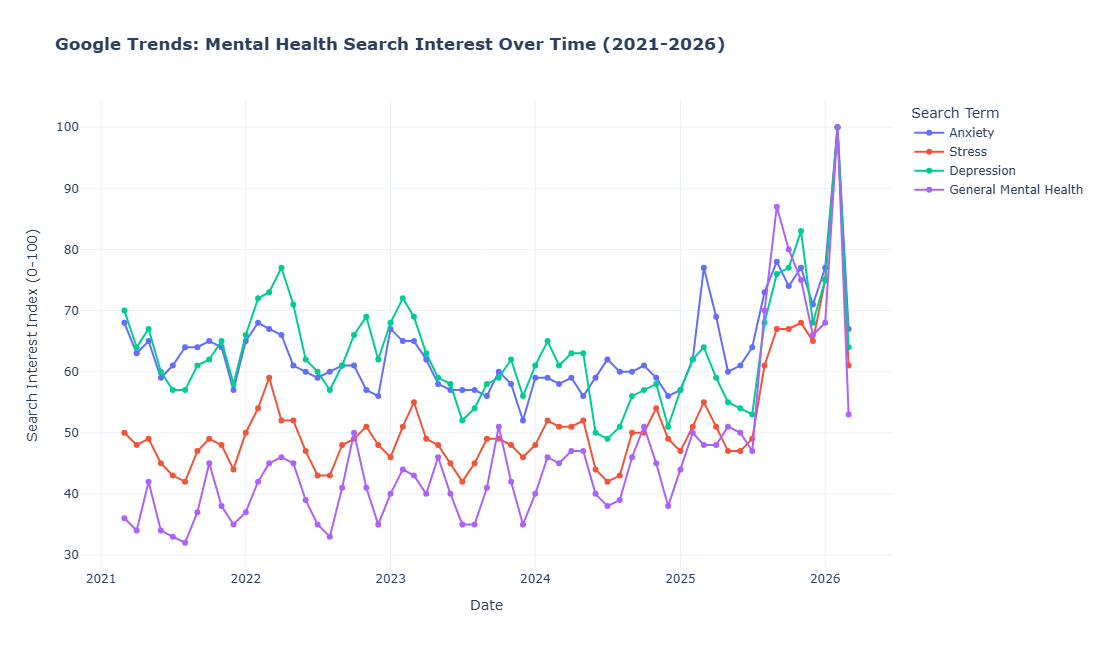

In [18]:
#Interactive Time Series Plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=df_trends.index, y=df_trends['Anxiety_Search_Index'],
                         mode='lines+markers', name='Anxiety', line=dict(color='#636EFA')))
fig.add_trace(go.Scatter(x=df_trends.index, y=df_trends['Stress_Search_Index'],
                         mode='lines+markers', name='Stress', line=dict(color='#EF553B')))
fig.add_trace(go.Scatter(x=df_trends.index, y=df_trends['Depression_Search_Index'],
                         mode='lines+markers', name='Depression', line=dict(color='#00CC96')))
fig.add_trace(go.Scatter(x=df_trends.index, y=df_trends['Mental_Health_General_Search_Index'],
                         mode='lines+markers', name='General Mental Health', line=dict(color='#AB63FA')))

fig.update_layout(
    title="<b>Google Trends: Mental Health Search Interest Over Time (2021-2026)</b>",
    xaxis_title="Date",
    yaxis_title="Search Interest Index (0-100)",
    height=650,
    width=1300,
    template="plotly_white",
    hovermode="x unified",
    legend_title="Search Term"
)

fig.show()

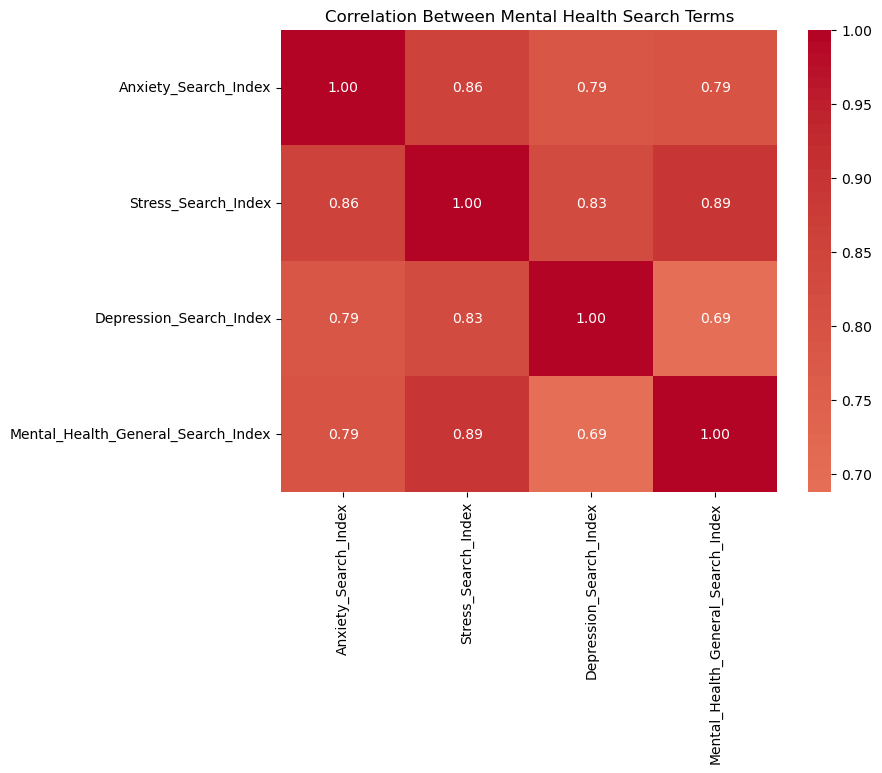

In [17]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df_trends.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Mental Health Search Terms')
plt.show()

In [14]:
# Key insights
print("\n=== KEY INSIGHTS ===")
print(f"Time period: {df_trends.index[0].strftime('%Y-%m')} to {df_trends.index[-1].strftime('%Y-%m')}")
print(f"Overall average search interest:")
print(df_trends.mean().round(2))


=== KEY INSIGHTS ===
Time period: 2021-03 to 2026-03
Overall average search interest:
Anxiety_Search_Index                  63.28
Stress_Search_Index                   51.33
Depression_Search_Index               63.07
Mental_Health_General_Search_Index    46.00
dtype: float64


In [15]:
# Find peak months
peaks = df_trends.idxmax()
print("\nPeak months:")
for col in df_trends.columns:
    print(f"- {col}: {peaks[col].strftime('%Y-%m')} (Index = {df_trends.loc[peaks[col], col]})")


Peak months:
- Anxiety_Search_Index: 2026-02 (Index = 100)
- Stress_Search_Index: 2026-02 (Index = 100)
- Depression_Search_Index: 2026-02 (Index = 100)
- Mental_Health_General_Search_Index: 2026-02 (Index = 100)


In [ ]:
## TODO: Investigate the universal peak in Feb 2026.
# Was there a major global event, a social media trend, or a change in Google's data normalization?

In [16]:
# Recent trend (last 6 months vs first 6 months)
recent = df_trends.iloc[-6:].mean()
early = df_trends.iloc[:6].mean()
print("\nRecent trend (last 6 months vs first 6 months):")
print((recent - early).round(2))


Recent trend (last 6 months vs first 6 months):
Anxiety_Search_Index                  14.33
Stress_Search_Index                   26.50
Depression_Search_Index               15.33
Mental_Health_General_Search_Index    38.50
dtype: float64
